### Plain SinBERT-large Fine-Tuning Model
This notebook fine-tunes the plain SinBERT-large (RoBERTa-based) model for Sinhala emotion classification **without** any CNN layers, using `RobertaForSequenceClassification`. Results can be directly compared with the SinBERT+CNN model.


### Imports


In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, RobertaForSequenceClassification
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


### Load Dataset


In [2]:
df = pd.read_csv('./processed/processed_dataset.csv')
print(f"Dataset shape: {df.shape}")
print(f"Label distribution:\n{df['label'].value_counts()}")

num_labels = len(df['label'].unique())
label_names = sorted(df['label'].unique())
label2idx = {label: idx for idx, label in enumerate(label_names)}
idx2label = {idx: label for label, idx in label2idx.items()}
print(f"\nNumber of labels: {num_labels}")
print(f"Label mapping: {label2idx}")


Dataset shape: (3155, 2)
Label distribution:
label
joy         606
disgust     540
sadness     507
fear        504
anger       502
surprise    496
Name: count, dtype: int64

Number of labels: 6
Label mapping: {'anger': 0, 'disgust': 1, 'fear': 2, 'joy': 3, 'sadness': 4, 'surprise': 5}


|### Tokenizer


In [3]:
tokenizer = AutoTokenizer.from_pretrained("NLPC-UOM/SinBERT-large")


### Dataset Class


In [ ]:
class SinhalaEmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.label2idx = {label: idx for idx, label in enumerate(sorted(set(labels)))}
        self.labels = [self.label2idx[label] for label in labels]
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

### Plain SinBERT Model Definition
This uses `RobertaForSequenceClassification` directly — a linear classification head on top of the pooled SinBERT output. No CNN layers are added. AdamW is used as the optimizer with weight decay for proper regularization.


In [5]:
class PlainSinBERT(nn.Module):
    """
    Plain SinBERT model for sequence classification.
    Uses RobertaForSequenceClassification with a linear head on top of the [CLS] token.
    No CNN layers — serves as a baseline for comparison.
    """
    def __init__(self, num_labels, dropout_rate=0.1, pretrained_model_name="NLPC-UOM/SinBERT-large"):
        super(PlainSinBERT, self).__init__()
        self.bert = RobertaForSequenceClassification.from_pretrained(
            pretrained_model_name,
            num_labels=num_labels,
            hidden_dropout_prob=dropout_rate,
            attention_probs_dropout_prob=dropout_rate,
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.logits


### Training Function with Early Stopping


In [6]:
def train_model_with_early_stopping(model, train_loader, val_loader, criterion, optimizer, device, epochs=10, patience=2):
    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * input_ids.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).float().sum().item()
            total += labels.size(0)

        epoch_loss = running_loss / total
        epoch_acc = correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        # Validation phase
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * input_ids.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).float().sum().item()
                val_total += labels.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                model.load_state_dict(best_model_state)
                break

    return train_losses, train_accuracies, val_losses, val_accuracies


### Evaluation Function


In [7]:
def evaluate_metrics(model, data_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')
    return acc, precision, recall, f1


### Data Preparation


In [8]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

BATCH_SIZE = 16

train_dataset = SinhalaEmotionDataset(
    texts=df_train['text'].tolist(),
    labels=df_train['label'].tolist(),
    tokenizer=tokenizer
)

test_dataset = SinhalaEmotionDataset(
    texts=df_test['text'].tolist(),
    labels=df_test['label'].tolist(),
    tokenizer=tokenizer
)

train_data_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_data_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print("Data loaders ready.")


Data loaders ready.


### Class Weights & Loss Function


In [ ]:
labels_array = df_train['label'].values
class_sample_count = np.array([np.sum(labels_array == t) for t in sorted(np.unique(labels_array))])
weight = 1. / class_sample_count
class_weights = torch.tensor(weight, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
print(f"Class weights (from training set only): {class_weights}")


### Hyperparameter Tuning (Grid Search)
The hyperparameters tuned for the plain model are:
- **learning_rate**: Controls the step size of AdamW optimizer updates
- **dropout_rate**: Controls regularization in the transformer layers
- **weight_decay**: The decoupled weight decay in AdamW for better generalization


In [ ]:
NUM_FROZEN_LAYERS = 12

def freeze_bottom_layers(model, num_frozen_layers=NUM_FROZEN_LAYERS):
    for param in model.bert.roberta.embeddings.parameters():
        param.requires_grad = False
    for i in range(num_frozen_layers):
        for param in model.bert.roberta.encoder.layer[i].parameters():
            param.requires_grad = False
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Frozen: embeddings + bottom {num_frozen_layers} encoder layers | Trainable: {trainable:,}/{total:,} ({100*trainable/total:.1f}%)")


In [ ]:
param_grid = {
    'learning_rate': [2e-5, 3e-5],
    'dropout_rate': [0.1, 0.2],
    'weight_decay': [0.01, 0.1],
}

all_combinations = list(itertools.product(
    param_grid['learning_rate'],
    param_grid['dropout_rate'],
    param_grid['weight_decay'],
))

results = []

for lr, drop, wd in tqdm(all_combinations, desc='Hyperparameter Tuning'):
    model = PlainSinBERT(
        num_labels=num_labels,
        dropout_rate=drop,
    ).to(device)
    freeze_bottom_layers(model)

    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=wd)

    train_model_with_early_stopping(
        model=model,
        train_loader=train_data_loader,
        val_loader=test_data_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=10,
        patience=2
    )

    acc, precision, recall, f1 = evaluate_metrics(model, test_data_loader, device)
    results.append({
        'params': f"lr={lr}, drop={drop}, wd={wd}",
        'learning_rate': lr,
        'dropout_rate': drop,
        'weight_decay': wd,
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })
    print(f"  lr={lr}, drop={drop}, wd={wd} → Acc={acc:.4f}, F1={f1:.4f}")


### Best Hyperparameters


In [11]:
best_result = max(results, key=lambda x: x['f1'])
print('Best hyperparameters:', best_result['params'])
print(f"  Accuracy:  {best_result['accuracy']:.4f}")
print(f"  Precision: {best_result['precision']:.4f}")
print(f"  Recall:    {best_result['recall']:.4f}")
print(f"  F1 Score:  {best_result['f1']:.4f}")


Best hyperparameters: lr=2e-05, drop=0.1, wd=0.01
  Accuracy:  0.7179
  Precision: 0.7187
  Recall:    0.7143
  F1 Score:  0.7135


### Hyperparameter Tuning Performance Plot


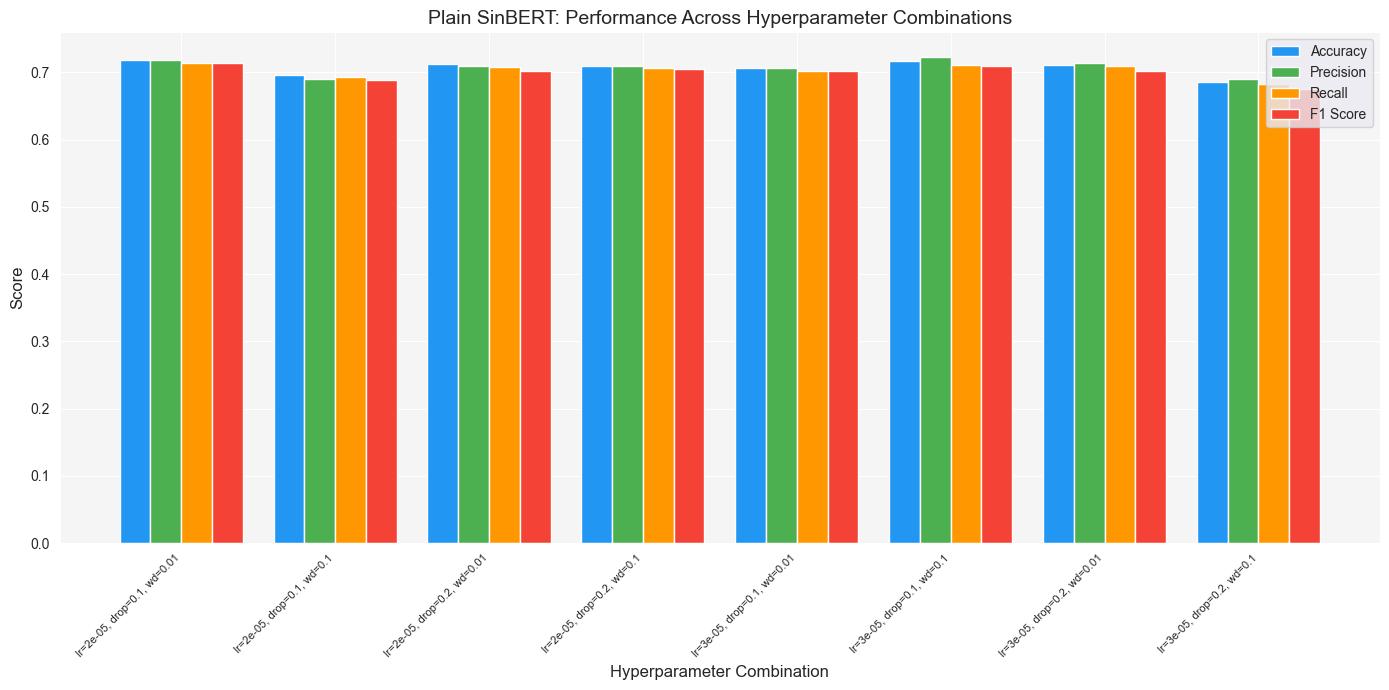

In [12]:
accuracies_hp = [r['accuracy'] for r in results]
precisions_hp = [r['precision'] for r in results]
recalls_hp = [r['recall'] for r in results]
f1s_hp = [r['f1'] for r in results]
labels_hp = [r['params'] for r in results]

fig, ax = plt.subplots(figsize=(14, 7))
x = range(len(results))
width = 0.2

ax.bar([i - 1.5*width for i in x], accuracies_hp, width, label='Accuracy', color='#2196F3')
ax.bar([i - 0.5*width for i in x], precisions_hp, width, label='Precision', color='#4CAF50')
ax.bar([i + 0.5*width for i in x], recalls_hp, width, label='Recall', color='#FF9800')
ax.bar([i + 1.5*width for i in x], f1s_hp, width, label='F1 Score', color='#F44336')

ax.set_xlabel('Hyperparameter Combination', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Plain SinBERT: Performance Across Hyperparameter Combinations', fontsize=14)
ax.set_xticks(list(x))
ax.set_xticklabels(labels_hp, rotation=45, ha='right', fontsize=8)
ax.legend()
ax.set_facecolor('#f5f5f5')
fig.patch.set_facecolor('#ffffff')
plt.tight_layout()
plt.savefig('./SS/plain_sinbert_hyperparam_tuning.png', dpi=150, bbox_inches='tight')
plt.show()


### 5-Fold Cross-Validation with Best Hyperparameters


In [ ]:
best_lr = best_result['learning_rate']
best_drop = best_result['dropout_rate']
best_wd = best_result['weight_decay']

k_folds = 5
kfolds = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
texts = df['text'].tolist()
labels_cv = df['label'].values

fold_results = []
train_losses_all = []
val_losses_all = []
all_labels_cv = []
all_preds_cv = []

for fold, (train_idx, val_idx) in enumerate(kfolds.split(texts, labels_cv)):
    print(f"\n{'='*50}")
    print(f"Fold {fold+1}/{k_folds}")
    print(f"{'='*50}")

    train_texts = [texts[i] for i in train_idx]
    train_labels = [labels_cv[i] for i in train_idx]
    val_texts = [texts[i] for i in val_idx]
    val_labels = [labels_cv[i] for i in val_idx]

    train_dataset = SinhalaEmotionDataset(train_texts, train_labels, tokenizer)
    val_dataset = SinhalaEmotionDataset(val_texts, val_labels, tokenizer)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

    model = PlainSinBERT(
        num_labels=num_labels,
        dropout_rate=best_drop,
    ).to(device)
    freeze_bottom_layers(model)

    optimizer = AdamW(model.parameters(), lr=best_lr, weight_decay=best_wd)

    # Per-fold class weights from training fold only
    fold_label_counts = np.array([train_labels.count(t) for t in sorted(set(train_labels))])
    fold_weight = 1. / fold_label_counts
    fold_class_weights = torch.tensor(fold_weight, dtype=torch.float).to(device)
    fold_criterion = nn.CrossEntropyLoss(weight=fold_class_weights)

    train_losses, train_accuracies, val_losses, val_accuracies = train_model_with_early_stopping(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=fold_criterion,
        optimizer=optimizer,
        device=device,
        epochs=10,
        patience=2
    )

    train_losses_all.append(train_losses)
    val_losses_all.append(val_losses)

    acc, precision, recall, f1 = evaluate_metrics(model, val_loader, device)

    model.eval()
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch = batch['labels'].cpu().numpy()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds_batch = torch.argmax(outputs, dim=1).cpu().numpy()
            all_labels_cv.extend(labels_batch)
            all_preds_cv.extend(preds_batch)

    fold_results.append({
        'fold': fold + 1,
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })
    print(f"Fold {fold+1} → Acc: {acc:.4f}, Prec: {precision:.4f}, Rec: {recall:.4f}, F1: {f1:.4f}")


### Cross-Validation Results


In [21]:
print("\n" + "="*60)
print("5-Fold Cross-Validation Results (Plain SinBERT)")
print("="*60)
for r in fold_results:
    print(f"  Fold {r['fold']}: Acc={r['accuracy']:.4f}, Prec={r['precision']:.4f}, Rec={r['recall']:.4f}, F1={r['f1']:.4f}")

print("\n--- Macro Performance (Averaged Across Folds) ---")
avg_accuracy = np.mean([r['accuracy'] for r in fold_results])
avg_precision = np.mean([r['precision'] for r in fold_results])
avg_recall = np.mean([r['recall'] for r in fold_results])
avg_f1 = np.mean([r['f1'] for r in fold_results])

accuracies_cv = [r['accuracy'] for r in fold_results]
precisions_cv = [r['precision'] for r in fold_results]
recalls_cv = [r['recall'] for r in fold_results]
f1s_cv = [r['f1'] for r in fold_results]

print(f"  Average Accuracy:  {avg_accuracy:.4f} ± {np.std(accuracies_cv):.4f}")
print(f"  Average Precision: {avg_precision:.4f} ± {np.std(precisions_cv):.4f}")
print(f"  Average Recall:    {avg_recall:.4f} ± {np.std(recalls_cv):.4f}")
print(f"  Average F1 Score:  {avg_f1:.4f} ± {np.std(f1s_cv):.4f}")



5-Fold Cross-Validation Results (Plain SinBERT)
  Fold 1: Acc=0.7147, Prec=0.7160, Rec=0.7121, F1=0.7086
  Fold 2: Acc=0.7132, Prec=0.7272, Rec=0.7093, F1=0.7142
  Fold 3: Acc=0.7211, Prec=0.7336, Rec=0.7178, F1=0.7197
  Fold 4: Acc=0.7274, Prec=0.7295, Rec=0.7221, F1=0.7222
  Fold 5: Acc=0.7036, Prec=0.7004, Rec=0.6995, F1=0.6966

--- Macro Performance (Averaged Across Folds) ---
  Average Accuracy:  0.7160 ± 0.0080
  Average Precision: 0.7213 ± 0.0120
  Average Recall:    0.7122 ± 0.0077
  Average F1 Score:  0.7123 ± 0.0091


### Per-Fold Metrics Bar Chart


In [ ]:
fold_nums = [f"Fold {r['fold']}" for r in fold_results]
x = np.arange(len(fold_nums))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - 1.5*width, accuracies_cv, width, label='Accuracy', color='#2196F3')
ax.bar(x - 0.5*width, precisions_cv, width, label='Precision', color='#4CAF50')
ax.bar(x + 0.5*width, recalls_cv, width, label='Recall', color='#FF9800')
ax.bar(x + 1.5*width, f1s_cv, width, label='F1 Score', color='#F44336')

ax.set_xlabel('Fold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Plain SinBERT: Per-Fold Cross-Validation Metrics', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(fold_nums)
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#f5f5f5')
fig.patch.set_facecolor('#ffffff')
plt.tight_layout()
plt.savefig('./SS/plain_sinbert_per_fold_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


### Training and Validation Loss Plot (Averaged Across Folds)


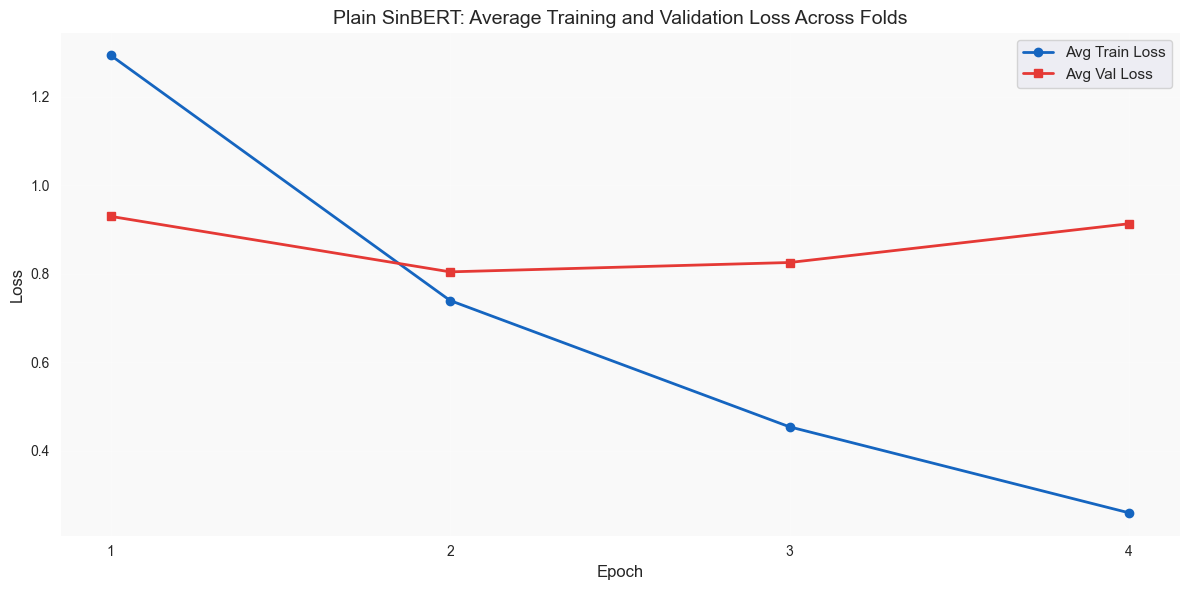

In [15]:
min_len = min(len(l) for l in train_losses_all)
train_losses_trimmed = [l[:min_len] for l in train_losses_all]
val_losses_trimmed = [l[:min_len] for l in val_losses_all]

avg_train_loss = np.mean(train_losses_trimmed, axis=0)
avg_val_loss = np.mean(val_losses_trimmed, axis=0)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(range(1, len(avg_train_loss)+1), avg_train_loss, marker='o', label='Avg Train Loss', color='#1565C0', linewidth=2)
ax.plot(range(1, len(avg_val_loss)+1), avg_val_loss, marker='s', label='Avg Val Loss', color='#E53935', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Plain SinBERT: Average Training and Validation Loss Across Folds', fontsize=14)
ax.set_xticks(range(1, len(avg_train_loss)+1))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('#ffffff')
plt.tight_layout()
plt.savefig('./SS/plain_sinbert_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()


### Per-Fold Loss Curves


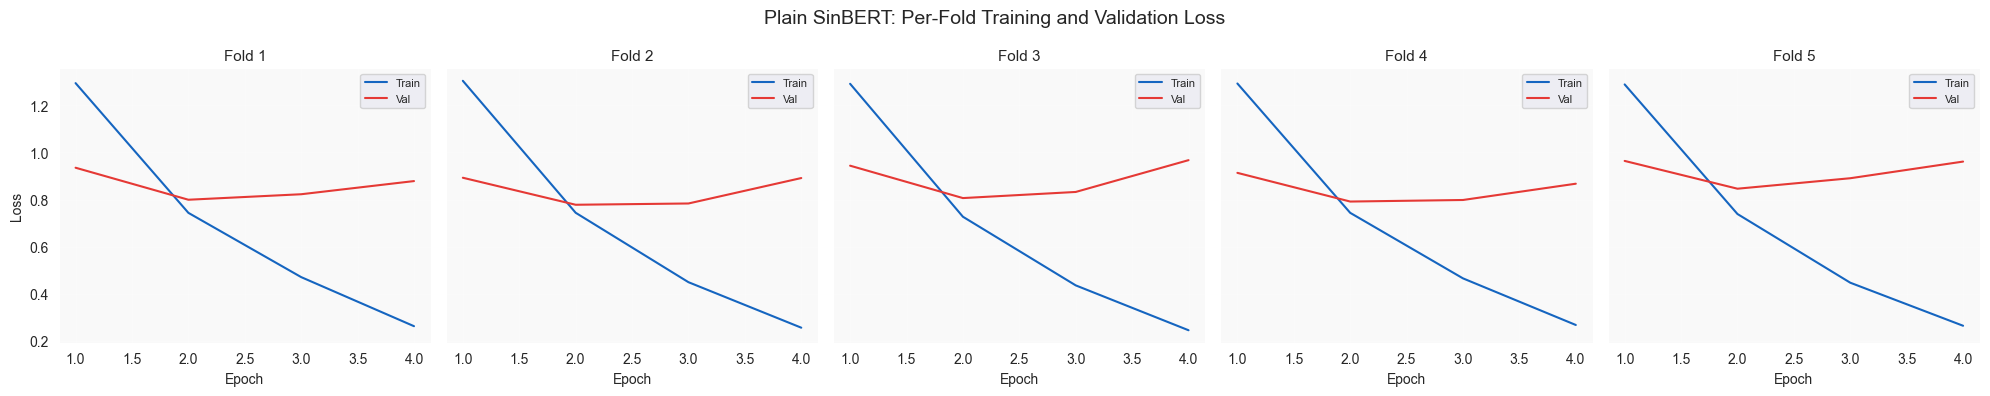

In [16]:
fig, axes = plt.subplots(1, k_folds, figsize=(20, 4), sharey=True)
for i in range(k_folds):
    axes[i].plot(range(1, len(train_losses_all[i])+1), train_losses_all[i], label='Train', color='#1565C0')
    axes[i].plot(range(1, len(val_losses_all[i])+1), val_losses_all[i], label='Val', color='#E53935')
    axes[i].set_title(f'Fold {i+1}', fontsize=11)
    axes[i].set_xlabel('Epoch')
    if i == 0:
        axes[i].set_ylabel('Loss')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_facecolor('#f9f9f9')

fig.suptitle('Plain SinBERT: Per-Fold Training and Validation Loss', fontsize=14)
fig.patch.set_facecolor('#ffffff')
plt.tight_layout()
plt.savefig('./SS/plain_sinbert_per_fold_loss.png', dpi=150, bbox_inches='tight')
plt.show()


### Confusion Matrix (Global / Micro Performance)


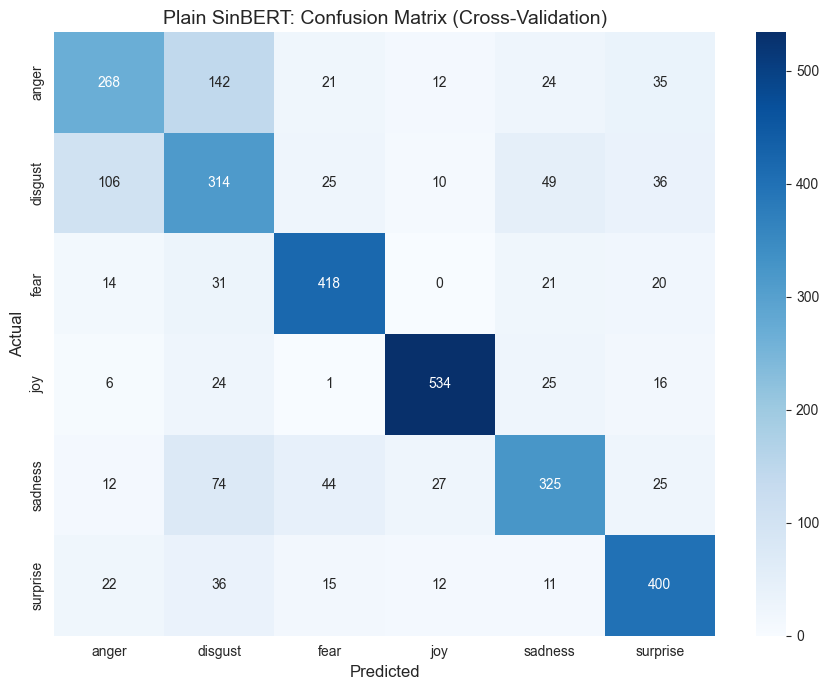

In [17]:
emotion_names = sorted(set(df['label'].values))

cm = confusion_matrix(all_labels_cv, all_preds_cv)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotion_names, yticklabels=emotion_names, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Plain SinBERT: Confusion Matrix (Cross-Validation)', fontsize=14)
fig.patch.set_facecolor('#ffffff')
plt.tight_layout()
plt.savefig('./SS/plain_sinbert_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


### Classification Report


In [18]:
print("\nDetailed Classification Report (Cross-Validation):")
print(classification_report(all_labels_cv, all_preds_cv, target_names=emotion_names))



Detailed Classification Report (Cross-Validation):
              precision    recall  f1-score   support

       anger       0.63      0.53      0.58       502
     disgust       0.51      0.58      0.54       540
        fear       0.80      0.83      0.81       504
         joy       0.90      0.88      0.89       606
     sadness       0.71      0.64      0.68       507
    surprise       0.75      0.81      0.78       496

    accuracy                           0.72      3155
   macro avg       0.72      0.71      0.71      3155
weighted avg       0.72      0.72      0.72      3155



### Micro Performance Metrics


In [19]:
micro_precision, micro_recall, micro_f1, _ = precision_recall_fscore_support(
    all_labels_cv, all_preds_cv, average='micro'
)
print("--- Micro Performance (Global) ---")
print(f"  Micro Precision: {micro_precision:.4f}")
print(f"  Micro Recall:    {micro_recall:.4f}")
print(f"  Micro F1 Score:  {micro_f1:.4f}")


--- Micro Performance (Global) ---
  Micro Precision: 0.7160
  Micro Recall:    0.7160
  Micro F1 Score:  0.7160


### Per-Class Performance Bar Chart


In [ ]:
per_class_precision, per_class_recall, per_class_f1, per_class_support = precision_recall_fscore_support(
    all_labels_cv, all_preds_cv, average=None
)

x = np.arange(len(emotion_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, per_class_precision, width, label='Precision', color='#4CAF50')
ax.bar(x, per_class_recall, width, label='Recall', color='#FF9800')
ax.bar(x + width, per_class_f1, width, label='F1 Score', color='#F44336')

ax.set_xlabel('Emotion Class', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Plain SinBERT: Per-Class Performance (Cross-Validation)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(emotion_names, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#f5f5f5')
fig.patch.set_facecolor('#ffffff')
plt.tight_layout()
plt.savefig('./SS/plain_sinbert_per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


### Summary for Comparison
Use these final metrics to compare **Plain SinBERT** with **SinBERT+CNN**:


In [20]:
print("="*60)
print("PLAIN SinBERT — FINAL COMPARISON METRICS")
print("="*60)
print(f"\n  Best Hyperparameters: {best_result['params']}")
print(f"  Optimizer: AdamW (lr={best_lr}, weight_decay={best_wd})")
print(f"  Dropout: {best_drop}")
print(f"\n  Macro Accuracy:  {avg_accuracy:.4f} ± {np.std(accuracies_cv):.4f}")
print(f"  Macro Precision: {avg_precision:.4f} ± {np.std(precisions_cv):.4f}")
print(f"  Macro Recall:    {avg_recall:.4f} ± {np.std(recalls_cv):.4f}")
print(f"  Macro F1 Score:  {avg_f1:.4f} ± {np.std(f1s_cv):.4f}")
print(f"\n  Micro Precision: {micro_precision:.4f}")
print(f"  Micro Recall:    {micro_recall:.4f}")
print(f"  Micro F1 Score:  {micro_f1:.4f}")
print("="*60)


PLAIN SinBERT — FINAL COMPARISON METRICS

  Macro Accuracy:  0.7160
  Macro Precision: 0.7213
  Macro Recall:    0.7122
  Macro F1 Score:  0.7123

  Micro Precision: 0.7160
  Micro Recall:    0.7160
  Micro F1 Score:  0.7160

  Best Hyperparameters: lr=2e-05, drop=0.1, wd=0.01
  Optimizer: AdamW (lr=2e-05, weight_decay=0.01)
  Dropout: 0.1


### Final Test Set Evaluation
Train one model on the full 80% training split with best hyperparameters and evaluate once on the held-out 20% test set.

In [ ]:
final_model = PlainSinBERT(
    num_labels=num_labels,
    dropout_rate=best_drop,
).to(device)
freeze_bottom_layers(final_model)

optimizer = AdamW(final_model.parameters(), lr=best_lr, weight_decay=best_wd)
criterion_final = nn.CrossEntropyLoss(weight=class_weights)

train_model_with_early_stopping(
    model=final_model,
    train_loader=train_data_loader,
    val_loader=test_data_loader,
    criterion=criterion_final,
    optimizer=optimizer,
    device=device,
    epochs=10,
    patience=2
)

acc, precision, recall, f1 = evaluate_metrics(final_model, test_data_loader, device)
print('=' * 50)
print('Final Test Set Evaluation (Plain SinBERT)')
print('=' * 50)
print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1 Score:  {f1:.4f}')
